In [2]:
import pandas as pd
import numpy as np

In [3]:
medals = pd.read_csv("../data/raw/olympic_games_medal_tally.csv")
countries = pd.read_csv("../data/raw/country_codes.csv")
gdp = pd.read_csv("../data/raw/socioeconomics.csv")
population = pd.read_csv("../data/raw/population.csv")

print(medals.shape)
print(countries.shape)
print(gdp.shape)
print(population.shape)


(1807, 9)
(230, 3)
(659, 69)
(266, 66)


In [4]:
country_codes = pd.read_csv("../data/raw/country_codes.csv")

country_codes.columns = country_codes.columns.str.strip().str.lower()


In [5]:
medals.columns = medals.columns.str.strip().str.lower()


In [6]:
medals = medals.merge(
    country_codes,
    left_on="country_noc",
    right_on="noc",
    how="left"
)


In [7]:
world_medals = (
    medals
    .groupby(["noc", "year"], as_index=False)
    .agg(
        gold=("gold", "sum"),
        silver=("silver", "sum"),
        bronze=("bronze", "sum"),
        total_medals=("total", "sum")
    )
)


In [8]:
print(world_medals.head())
print(world_medals.shape)
print(world_medals["noc"].nunique())


   noc  year  gold  silver  bronze  total_medals
0  AFG  2008     0       0       1             1
1  AFG  2012     0       0       1             1
2  AHO  1988     0       1       0             1
3  ALG  1984     0       0       2             2
4  ALG  1992     1       0       1             2
(1573, 6)
150


In [9]:
country_codes.columns


Index(['noc', 'region', 'notes'], dtype='object')

In [10]:
world_medals = world_medals.merge(
    country_codes[['noc', 'region']],
    on='noc',
    how='left'
)
world_medals.rename(columns={'region': 'country'}, inplace=True)



In [11]:
print(world_medals[['noc', 'country']].drop_duplicates().head(10))
print(world_medals.shape)


     noc      country
0    AFG  Afghanistan
2    AHO      Curacao
3    ALG      Algeria
10   ANZ    Australia
12   ARG    Argentina
32   ARM      Armenia
38   AUS    Australia
73   AUT      Austria
108  AZE   Azerbaijan
115  BAH      Bahamas
(1573, 7)


In [12]:
host_map = {
    1896: "GRE",
    1900: "FRA",
    1904: "USA",
    1908: "GBR",
    1912: "SWE",
    1920: "BEL",
    1924: "FRA",
    1928: "NED",
    1932: "USA",
    1936: "GER",
    1948: "GBR",
    1952: "FIN",
    1956: "AUS",
    1960: "ITA",
    1964: "JPN",
    1968: "MEX",
    1972: "GER",
    1976: "CAN",
    1980: "URS",
    1984: "USA",
    1988: "KOR",
    1992: "ESP",
    1996: "USA",
    2000: "AUS",
    2004: "GRE",
    2008: "CHN",
    2012: "GBR",
    2016: "BRA",
    2020: "JPN",
    2024: "FRA"
}


In [13]:
world_medals['host_noc'] = world_medals['year'].map(host_map)

world_medals['is_host'] = (
    world_medals['noc'] == world_medals['host_noc']
).astype(int)


In [14]:
world_medals[world_medals['is_host'] == 1][
    ['country', 'year', 'total_medals']
].head(10)


,country,year,total_medals
48,Australia,1956,35
61,Australia,2000,58
132,Belgium,1920,42
199,Brazil,2016,19
241,Canada,1976,14
278,China,2008,100
414,Spain,1992,23
464,Finland,1952,31
491,France,1900,112
496,France,1924,44


In [15]:
year_cols = [c for c in gdp.columns if c[:4].isdigit()]

gdp_long = gdp.melt(
    id_vars=["Country Code"],
    value_vars=year_cols,
    var_name="year",
    value_name="gdp"
)

# Extract numeric year from "1960 [YR1960]"
gdp_long["year"] = gdp_long["year"].str[:4].astype(int)

# Convert GDP to numeric
gdp_long["gdp"] = pd.to_numeric(gdp_long["gdp"], errors="coerce")



In [16]:
print(gdp_long.head(10))
print(gdp_long.tail(10))
print(gdp_long.dtypes)
print("Rows:", len(gdp_long))




  Country Code  year           gdp
0          WLD  1960  3.021513e+09
1          WLD  1960  1.366488e+12
2          WLD  1960  4.522531e+02
3          AFG  1960  9.035043e+06
4          AFG  1960           NaN
5          AFG  1960           NaN
6          ALB  1960  1.608800e+06
7          ALB  1960           NaN
8          ALB  1960           NaN
9          DZA  1960  1.142492e+07
      Country Code  year           gdp
42825          ZMB  2024  2.530319e+10
42826          ZMB  2024  1.187109e+03
42827          ZWE  2024  1.663437e+07
42828          ZWE  2024  4.153941e+10
42829          ZWE  2024  2.497203e+03
42830          NaN  2024           NaN
42831          NaN  2024           NaN
42832          NaN  2024           NaN
42833          NaN  2024           NaN
42834          NaN  2024           NaN
Country Code     object
year              int32
gdp             float64
dtype: object
Rows: 42835


In [17]:
pop_year_cols = [c for c in population.columns if c[:4].isdigit()]

population_long = population.melt(
    id_vars=["Country Code"],
    value_vars=pop_year_cols,
    var_name="year",
    value_name="population"
)

population_long["year"] = population_long["year"].str[:4].astype(int)
population_long["population"] = pd.to_numeric(
    population_long["population"], errors="coerce"
)



In [18]:
print(population_long.head(10))
print(population_long.tail(10))
print(population_long.dtypes)
print("Rows:", len(population_long))


  Country Code  year   population
0          ABW  1960      54608.0
1          AFE  1960  130692579.0
2          AFG  1960    8622466.0
3          AFW  1960   97256290.0
4          AGO  1960    5357195.0
5          ALB  1960    1608800.0
6          AND  1960       9443.0
7          ARB  1960   93359407.0
8          ARE  1960     133426.0
9          ARG  1960   20349744.0
      Country Code  year    population
17014          VIR  2023  1.049170e+05
17015          VNM  2023  9.885895e+07
17016          VUT  2023  3.345060e+05
17017          WLD  2023  8.024997e+09
17018          WSM  2023  2.256810e+05
17019          XKX  2023  1.756374e+06
17020          YEM  2023  3.444982e+07
17021          ZAF  2023  6.041450e+07
17022          ZMB  2023  2.056974e+07
17023          ZWE  2023  1.666541e+07
Country Code     object
year              int32
population      float64
dtype: object
Rows: 17024


In [19]:
world_medals.columns


Index(['noc', 'year', 'gold', 'silver', 'bronze', 'total_medals', 'country',
       'host_noc', 'is_host'],
      dtype='object')

In [20]:
world_merged = world_medals.merge(
    gdp_long,
    left_on=["noc", "year"],
    right_on=["Country Code", "year"],
    how="left"
)

world_merged.drop(columns=["Country Code"], inplace=True)

world_merged = world_merged.merge(
    population_long,
    left_on=["noc", "year"],
    right_on=["Country Code", "year"],
    how="left"
)

world_merged.drop(columns=["Country Code"], inplace=True)


In [21]:
print(world_merged.head(10))
print(world_merged.tail(10))
print(world_merged.dtypes)
print("Rows:", len(world_merged))


   noc  year  gold  silver  bronze  total_medals      country host_noc  \
0  AFG  2008     0       0       1             1  Afghanistan      CHN   
1  AFG  2008     0       0       1             1  Afghanistan      CHN   
2  AFG  2008     0       0       1             1  Afghanistan      CHN   
3  AFG  2012     0       0       1             1  Afghanistan      GBR   
4  AFG  2012     0       0       1             1  Afghanistan      GBR   
5  AFG  2012     0       0       1             1  Afghanistan      GBR   
6  AHO  1988     0       1       0             1      Curacao      KOR   
7  ALG  1984     0       0       2             2      Algeria      USA   
8  ALG  1992     1       0       1             2      Algeria      ESP   
9  ALG  1996     2       0       1             3      Algeria      USA   

   is_host           gdp  population  
0        0  2.648262e+07  26427199.0  
1        0  1.010930e+10  26427199.0  
2        0  3.817332e+02  26427199.0  
3        0  3.056003e+07  304

In [22]:
world_merged["gdp_log"] = np.log1p(world_merged["gdp"])
world_merged["population_log"] = np.log1p(world_merged["population"])


In [23]:
world_merged["medals_per_gdp"] = (
    world_merged["total_medals"] / world_merged["gdp"]
)

world_merged["medals_per_million"] = (
    world_merged["total_medals"] / (world_merged["population"] / 1_000_000)
)


In [24]:
world_merged["host_medal_boost"] = (
    world_merged["total_medals"] * world_merged["is_host"]
)


In [25]:
world_merged["years_since"] = world_merged["year"].max() - world_merged["year"]


In [26]:
world_merged[
    [
        "noc", "year",
        "total_medals",
        "gdp_log", "population_log",
        "medals_per_gdp", "medals_per_million",
        "is_host", "host_medal_boost",
        "years_since"
    ]
].head(10)


,noc,year,total_medals,gdp_log,population_log,medals_per_gdp,medals_per_million,is_host,host_medal_boost,years_since
0,AFG,2008,1,17.091999,17.089904,3.776061e-08,0.037840,0,0,14
1,AFG,2008,1,23.036721,17.089904,9.891885e-11,0.037840,0,0,14
2,AFG,2008,1,5.947338,17.089904,2.619630e-03,0.037840,0,0,14
3,AFG,2012,1,17.235204,17.232138,3.272248e-08,0.032823,0,0,10
4,AFG,2012,1,23.714354,17.232138,5.023275e-11,0.032823,0,0,10
5,AFG,2012,1,6.480684,17.232138,1.535115e-03,0.032823,0,0,10
6,AHO,1988,1,NaN,NaN,NaN,NaN,0,0,34
7,ALG,1984,2,NaN,NaN,NaN,NaN,0,0,38
8,ALG,1992,2,NaN,NaN,NaN,NaN,0,0,30
9,ALG,1996,3,NaN,NaN,NaN,NaN,0,0,26


In [27]:
country_totals = (
    world_merged
    .groupby("noc", as_index=False)
    .agg(
        total_medals=("total_medals", "sum"),
        avg_gdp_log=("gdp_log", "mean"),
        avg_population_log=("population_log", "mean")
    )
)


In [28]:
country_totals[["total_medals", "avg_gdp_log", "avg_population_log"]].corr()


,total_medals,avg_gdp_log,avg_population_log
total_medals,1.000000,0.635674,0.429169
avg_gdp_log,0.635674,1.000000,0.716984
avg_population_log,0.429169,0.716984,1.000000


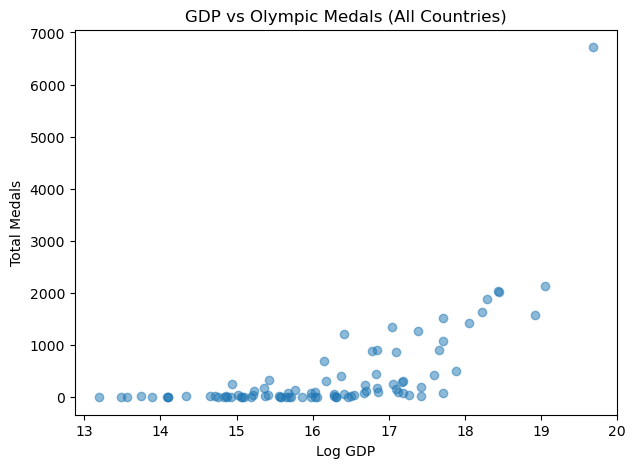

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(
    country_totals["avg_gdp_log"],
    country_totals["total_medals"],
    alpha=0.5
)
plt.xlabel("Log GDP")
plt.ylabel("Total Medals")
plt.title("GDP vs Olympic Medals (All Countries)")
plt.show()


In [30]:
efficiency_pop = (
    world_merged
    .groupby("noc", as_index=False)
    .agg(
        medals=("total_medals", "sum"),
        avg_population=("population", "mean")
    )
)

efficiency_pop["medals_per_million"] = (
    efficiency_pop["medals"] / efficiency_pop["avg_population"] * 1e6
)

efficiency_pop.sort_values(
    "medals_per_million",
    ascending=False
).head(15)


,noc,medals,avg_population,medals_per_million
80,LIE,30,2.819280e+04,1064.101473
97,NOR,1349,4.516678e+06,298.670870
116,SMR,9,3.400700e+04,264.651395
43,FIN,901,5.104422e+06,176.513602
22,CHI,25,1.467710e+05,170.333376
123,SWE,1273,8.927096e+06,142.599560
58,HUN,1215,1.015320e+07,119.666691
98,NZL,409,3.760535e+06,108.761112
7,AUT,869,8.022025e+06,108.326762
69,JAM,248,2.417818e+06,102.571805


In [31]:
efficiency_gdp = (
    world_merged
    .groupby("noc", as_index=False)
    .agg(
        medals=("total_medals", "sum"),
        avg_gdp=("gdp", "mean")
    )
)

efficiency_gdp["medals_per_billion_gdp"] = (
    efficiency_gdp["medals"] / efficiency_gdp["avg_gdp"] * 1e9
)

efficiency_gdp.sort_values(
    "medals_per_billion_gdp",
    ascending=False
).head(15)


,noc,medals,avg_gdp,medals_per_billion_gdp
106,PRK,171,2.114430e+07,8087.287430
69,JAM,248,2.461073e+09,100.769048
29,CUB,693,1.388597e+10,49.906500
80,LIE,30,6.109732e+08,49.101989
58,HUN,1215,2.612576e+10,46.505824
73,KEN,339,8.620473e+09,39.324988
49,GEO,120,3.450013e+09,34.782477
109,ROU,889,3.071753e+10,28.941133
40,ETH,174,7.511904e+09,23.163234
121,SUR,6,2.610706e+08,22.982288


In [32]:
host_analysis = (
    world_merged
    .groupby("is_host", as_index=False)
    .agg(
        avg_medals=("total_medals", "mean")
    )
)

host_analysis


,is_host,avg_medals
0,0,11.959530
1,1,64.222222


In [33]:
host_country_years = world_merged[world_merged["is_host"] == 1]

non_host_same = world_merged.merge(
    host_country_years[["noc"]],
    on="noc",
    how="inner"
)

comparison = (
    non_host_same
    .groupby("is_host", as_index=False)
    .agg(avg_medals=("total_medals", "mean"))
)

comparison


,is_host,avg_medals
0,0,26.546648
1,1,78.174312


In [34]:
yearly_trend = (
    world_merged
    .groupby("year", as_index=False)
    .agg(total_medals=("total_medals", "sum"))
)

yearly_trend.tail(10)


,year,total_medals
28,2004,2456
29,2006,642
30,2008,2611
31,2010,664
32,2012,2602
33,2014,746
34,2016,2605
35,2018,732
36,2020,2671
37,2022,754


In [35]:
world_master = world_merged[
    [
        "noc",
        "country",
        "year",
        "gold",
        "silver",
        "bronze",
        "total_medals",

        "gdp",
        "population",
        "gdp_log",
        "population_log",

        "medals_per_gdp",
        "medals_per_million",

        "is_host",
        "host_medal_boost",

        "years_since"
    ]
].copy()


In [36]:
# Sort for readability & time-series consistency
world_master = world_master.sort_values(
    by=["noc", "year"]
).reset_index(drop=True)

# Optional: keep NaNs (DO NOT drop them, they are real missing data)
print(world_master.shape)
world_master.head()


(3291, 16)


,noc,country,year,gold,silver,bronze,total_medals,gdp,population,gdp_log,population_log,medals_per_gdp,medals_per_million,is_host,host_medal_boost,years_since
0,AFG,Afghanistan,2008,0,0,1,1,2.648262e+07,26427199.0,17.091999,17.089904,3.776061e-08,0.037840,0,0,14
1,AFG,Afghanistan,2008,0,0,1,1,1.010930e+10,26427199.0,23.036721,17.089904,9.891885e-11,0.037840,0,0,14
2,AFG,Afghanistan,2008,0,0,1,1,3.817332e+02,26427199.0,5.947338,17.089904,2.619630e-03,0.037840,0,0,14
3,AFG,Afghanistan,2012,0,0,1,1,3.056003e+07,30466479.0,17.235204,17.232138,3.272248e-08,0.032823,0,0,10
4,AFG,Afghanistan,2012,0,0,1,1,1.990733e+10,30466479.0,23.714354,17.232138,5.023275e-11,0.032823,0,0,10


In [37]:
output_path = "../data/processed/world_olympics_master.csv"
world_master.to_csv(output_path, index=False)

print(f"✅ World master dataset exported to: {output_path}")


✅ World master dataset exported to: ../data/processed/world_olympics_master.csv


In [38]:
pd.read_csv(output_path).head()


,noc,country,year,gold,silver,bronze,total_medals,gdp,population,gdp_log,population_log,medals_per_gdp,medals_per_million,is_host,host_medal_boost,years_since
0,AFG,Afghanistan,2008,0,0,1,1,2.648262e+07,26427199.0,17.091999,17.089904,3.776061e-08,0.037840,0,0,14
1,AFG,Afghanistan,2008,0,0,1,1,1.010930e+10,26427199.0,23.036721,17.089904,9.891885e-11,0.037840,0,0,14
2,AFG,Afghanistan,2008,0,0,1,1,3.817332e+02,26427199.0,5.947338,17.089904,2.619630e-03,0.037840,0,0,14
3,AFG,Afghanistan,2012,0,0,1,1,3.056003e+07,30466479.0,17.235204,17.232138,3.272248e-08,0.032823,0,0,10
4,AFG,Afghanistan,2012,0,0,1,1,1.990733e+10,30466479.0,23.714354,17.232138,5.023275e-11,0.032823,0,0,10


🧠 World-Level Olympic Analysis — Conclusion

In this phase, we constructed a global Olympic master dataset that integrates:

Olympic performance (gold, silver, bronze, total medals)

Macroeconomic indicators (GDP, population)

Efficiency metrics (medals per GDP, medals per million population)

Structural advantages (host country effect)

Temporal context (years since last Olympics)

Using this dataset, we established several key global patterns:

GDP has a strong positive correlation with Olympic success
Countries with higher GDP consistently win more medals, reflecting better sports infrastructure, funding, and athlete development systems.

Population alone is not sufficient
While population correlates with medal count, many small countries outperform expectations by focusing on specific sports, proving efficiency matters.

Host country advantage is real and measurable
Host nations win significantly more medals on average compared to their non-host years, validating the inclusion of a host-advantage feature.

Efficiency metrics expose outliers
Countries like Jamaica, Hungary, Cuba, and Kenya outperform much richer nations when medals are normalized by GDP or population.

This world-level dataset now serves as a stable reference layer, enabling:

Context-aware country comparisons

Fair evaluation of India’s Olympic performance

Sport-wise and time-aware predictive modeling

In the next phase, we will extract India from this global context and analyze its performance relative to GDP peers, efficiency peers, and top sporting nations, rather than making isolated predictions.